# Notebook A — Predicting Polymarket Price Level
## 2024 US Presidential Election — Walk-Forward Machine Learning

**Target variable:** `polymarket_trump_prob` — the daily closing probability that Donald Trump wins the 2024 US presidential election, as traded on Polymarket (a prediction market). Values range from 0 to 1.

**Goal:** Forecast whether tomorrow's Polymarket probability is higher or lower than today's, using same-day social media, news sentiment, polls, and financial data. If markets are informationally efficient, this should be nearly impossible using publicly available data — and that is exactly what we test.

**What this notebook does:**
1. Loads the pre-built feature matrix (`basetable.csv`)
2. Computes SBERT semantic embeddings from full daily text (pre-trained, no leakage)
3. Builds walk-forward CV splits that strictly respect the time order
4. Tunes and evaluates Ridge, Lasso, ElasticNet, XGBoost (+ text variants)
5. Visualises predictions, feature importance, and held-out test performance

**Notebook B** (`models_v2.ipynb`) uses the same pipeline but targets the
**first difference** of price (daily change) instead of the level.


<!-- toc -->
## Contents
- [2024 US Presidential Election — Walk-Forward Machine Learning](#2024-us-presidential-election-walk-forward-machine-learning)
- [1. Setup](#1-setup)
- [2. Data Loading & Feature Groups](#2-data-loading-feature-groups)
- [3. Walk-Forward CV Splits](#3-walk-forward-cv-splits)
  - [Why walk-forward (not k-fold)?](#why-walk-forward-not-k-fold)
  - [No fit-transform leakage](#no-fit-transform-leakage)
- [4. Preprocessing Pipeline (No Leakage)](#4-preprocessing-pipeline-no-leakage)
- [5. Hyperparameter Tuning](#5-hyperparameter-tuning)
- [6. Tuning Results](#6-tuning-results)
- [7. Walk-Forward CV Evaluation](#7-walk-forward-cv-evaluation)
- [8. Results](#8-results)
- [9. Predictions vs Actual — Best Model](#9-predictions-vs-actual-best-model)
- [10. Feature Importance](#10-feature-importance)
- [Feature Relevance — Model-free Correlation with Price Level](#feature-relevance-model-free-correlation-with-price-level)
- [11. Final Test Set Evaluation](#11-final-test-set-evaluation)


## 1. Setup

Standard library imports. `apply_style()` applies a consistent matplotlib theme defined in `house_style.py`. Helper functions for walk-forward splits and scoring are imported from `cv_utils.py` in the same directory.

**Key helper functions used throughout:**
- `get_test_tv_split(df, TEST_DAYS)` — holds out the last N days as the final test set
- `get_cv_folds(df, n_splits, gap, test_days)` — creates walk-forward folds on the
  training+validation portion
- `score_fold(pipe, feat_cols, train_idx, val_idx)` — fits a pipeline on `train_idx`,
  predicts on `val_idx`, returns MAE


In [1]:
import sys, os, warnings, itertools
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../Functions'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — skipping (pip install xgboost)")

from data_splits import get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage
from house_style import (
    apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, REPUBLICAN, DEMOCRAT, ACCENT,
    NEUTRAL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR, PALETTE
)
apply_style()
print("Setup complete.")

Setup complete.


## 2. Data Loading & Feature Groups

We load `basetable.csv` — a 124-row daily time series from 2024-07-04 to 2024-11-04. Each row is one calendar day. The 118+ columns come from six sources:

| Source | Examples |
|--------|----------|
| Bluesky | post count, sentiment avg/std, network density |
| Reddit | post share, VADER sentiment (Trump & Harris), cross-sub ratio |
| MediaCloud news | headline count, VADER + FinBERT sentiment, topic shares |
| Polls | Trump/Harris avg, margin, 7-day rolling avg |
| Financials | S&P500 return, VIX, oil, USD index, macro indicators |
| Calendar | days to election, event dummies (debate, assassination attempts) |

**Feature selection:** Columns with > 30 % missing values are dropped. The `polymarket_trump_prob_lag1` (yesterday's price) is always included as the autoregressive baseline — if AR(1) is hard to beat, that itself is evidence of market efficiency.

**No same-day leakage from the target:** All same-day features are available by end-of-day (social media posts, news articles, poll releases all precede the 00:03 UTC Polymarket scrape that defines the label).

In [15]:
df = pd.read_csv('../Data/3_Gold/basetable.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

TARGET = 'polymarket_trump_prob'

# Drop columns with > 30% NaN — too sparse to impute reliably
nan_pct   = df.isna().mean()
DROP_SPARSE = list(nan_pct[nan_pct > 0.30].index)
EXCL        = ['date', TARGET]
print(f"Dropping {len(DROP_SPARSE)} sparse columns: {DROP_SPARSE}")

ALL_FEAT = [c for c in df.columns if c not in DROP_SPARSE + EXCL]

FEAT_AR    = ['polymarket_trump_prob_lag1']
FEAT_POLLS = FEAT_AR + ['poll_trump_avg', 'poll_harris_avg',
                         'poll_margin', 'poll_trump_7d_avg']
FEAT_ALL   = ALL_FEAT   # lag1 already in ALL_FEAT (not in EXCL)

print(f"\nFeature set sizes:  AR={len(FEAT_AR)}  |  Polls={len(FEAT_POLLS)}  |  All={len(FEAT_ALL)}")
print(f"Rows: {len(df)}  |  {df['date'].min().date()} → {df['date'].max().date()}")
# ── Text (TF-IDF/LSA) features from text_features.ipynb ─────────────────────
# Run Predictive/text_features.ipynb first to generate this file.
try:
    text_feat = pd.read_csv('../Data/3_Gold/text_features.csv', parse_dates=['date'])
    df = df.merge(text_feat, on='date', how='left')
    TEXT_COLS = [c for c in text_feat.columns if c != 'date']
    FEAT_TEXT = ['polymarket_trump_prob_lag1'] + TEXT_COLS
    FEAT_ALL_TEXT = FEAT_ALL + TEXT_COLS
    print(f"Text features loaded: {len(TEXT_COLS)} LSA components")
    HAS_TEXT = True
except FileNotFoundError:
    print("text_features.csv not found — run text_features.ipynb first")
    FEAT_TEXT = FEAT_ALL
    FEAT_ALL_TEXT = FEAT_ALL
    HAS_TEXT = False
# ── Raw text features (aggregated per day in text_features.ipynb) ─────────────
# TF-IDF is NOT pre-computed here — it is fitted per fold inside the pipeline
# to prevent leakage of IDF weights from validation/test into training data.
try:
    text_raw = pd.read_csv('../Data/3_Gold/text_raw_daily.csv', parse_dates=['date'])
    for col in ['bsky_text', 'reddit_text', 'news_text']:
        text_raw[col] = text_raw[col].fillna('')
    df = df.merge(text_raw[['date','bsky_text','reddit_text','news_text']],
                  on='date', how='left')
    for col in ['bsky_text','reddit_text','news_text']:
        df[col] = df[col].fillna('')
    TEXT_COLS = ['bsky_text', 'reddit_text', 'news_text']
    HAS_TEXT  = True
    print(f"Raw text loaded: {len(TEXT_COLS)} text columns merged")
except FileNotFoundError:
    print("text_raw_daily.csv not found — run text_features.ipynb first")
    TEXT_COLS = []
    HAS_TEXT  = False

Dropping 8 sparse columns: ['sp500_vol_30d', 'sp500_dist_from_high_30d', 'sp500_dist_from_low_30d', 'sp500_zscore_30d', 'sp500_sma_cross_7_30', 'oil_dist_from_high_30d', 'oil_zscore_30d', 'macro_real_gdp']

Feature set sizes:  AR=1  |  Polls=5  |  All=119
Rows: 124  |  2024-07-04 → 2024-11-04
text_features.csv not found — run text_features.ipynb first
Raw text loaded: 3 text columns merged


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SBERT — Semantic Embeddings on Full Daily Text
#
# Pre-computed features are loaded from sbert_features_cache.csv.
# The cache was built with all-MiniLM-L6-v2 (22M params, fixed pre-trained
# weights) on 50 sampled sentences per day per source, then PCA 384->5.
# No data leakage: SBERT weights are fixed (not trained on our data).
# To recompute: delete the cache file and re-run the pre-compute script.
# ─────────────────────────────────────────────────────────────────────────────
import os as _os, warnings as _w
_w.filterwarnings("ignore")

SBERT_CACHE = "../Data/3_Gold/sbert_features_cache.csv"

if not _os.path.exists(SBERT_CACHE):
    print(f"WARNING: {SBERT_CACHE} not found.")
    print("Run the pre-compute script to generate it: python _precompute_sbert.py")
    FULL_TEXT_SBERT_FEATS = []
else:
    sbert_cache = pd.read_csv(SBERT_CACHE, parse_dates=["date"])
    # Only merge columns not already in df
    _new_cols = [c for c in sbert_cache.columns if c != "date" and c not in df.columns]
    if _new_cols:
        df = df.merge(sbert_cache[["date"] + _new_cols], on="date", how="left")
    FULL_TEXT_SBERT_FEATS = [c for c in sbert_cache.columns if c != "date"]
    print(f"SBERT cache loaded: {len(FULL_TEXT_SBERT_FEATS)} features")
    print(FULL_TEXT_SBERT_FEATS)

# -- Extend FEAT_ALL with SBERT columns ─────────────────────────────────────
if FULL_TEXT_SBERT_FEATS:
    FEAT_ALL      = list(set(FEAT_ALL)      | set(FULL_TEXT_SBERT_FEATS))
    FEAT_ALL_TEXT = list(set(FEAT_ALL_TEXT) | set(FULL_TEXT_SBERT_FEATS))
    print(f"FEAT_ALL extended to {len(FEAT_ALL)} features (SBERT included)")


SBERT cache loaded: 15 features
['sbert_bsky_pc1', 'sbert_bsky_pc2', 'sbert_bsky_pc3', 'sbert_bsky_pc4', 'sbert_bsky_pc5', 'sbert_reddit_pc1', 'sbert_reddit_pc2', 'sbert_reddit_pc3', 'sbert_reddit_pc4', 'sbert_reddit_pc5', 'sbert_news_pc1', 'sbert_news_pc2', 'sbert_news_pc3', 'sbert_news_pc4', 'sbert_news_pc5']
FEAT_ALL extended to 134 features (SBERT included)


## 3. Walk-Forward CV Splits

### Why walk-forward (not k-fold)?
Standard k-fold randomly shuffles rows, so the model can be trained on data from 2024-10-15 to predict 2024-08-01. That would be **look-ahead bias**: in real trading you never know the future.

Walk-forward CV respects the time axis:
- Training window: all days **before** the validation window
- A **gap of 1 day** between train and validation prevents any leakage from   features computed with rolling windows that span the boundary
- Each validation fold covers **14 days** (≈ 2 election weeks)

```
Day:   1 ──────────────────────────────────────────────────────── 124
Fold 1: [====TRAIN====][ gap ][ VAL 14d ]                        TEST
Fold 2: [========TRAIN========][ gap ][ VAL 14d ]                TEST
Fold 3: [============TRAIN============][ gap ][ VAL 14d ]        TEST
                                                          [TEST 14d]
```

### No fit-transform leakage
Every preprocessing step (imputation, scaling, TF-IDF) is wrapped in a `sklearn.Pipeline` that is **re-fitted from scratch on each training fold**. The validation rows are only `transform`-ed, never `fit`-ed.

In [4]:
TEST_DAYS = 14
N_SPLITS  = 3
GAP       = 1

tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)
folds = get_cv_folds(df, n_splits=N_SPLITS, gap=GAP, test_days=TEST_DAYS)

print(f"Train/val : {len(tv_idx)} rows  "
      f"({df['date'].iloc[tv_idx[0]].date()} → {df['date'].iloc[tv_idx[-1]].date()})")
print(f"Test      : {len(test_idx)} rows  "
      f"({df['date'].iloc[test_idx[0]].date()} → {df['date'].iloc[test_idx[-1]].date()})")
print()
print_fold_summary(df, folds)
print()
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df, gap=GAP)
    print(f"  Fold {i} leakage check: OK")

Train/val : 110 rows  (2024-07-04 → 2024-10-21)
Test      : 14 rows  (2024-10-22 → 2024-11-04)

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-04    2024-07-31       28    2024-08-02    2024-08-28      27
   2    2024-07-04    2024-08-27       55    2024-08-29    2024-09-24      27
   3    2024-07-04    2024-09-23       82    2024-09-25    2024-10-21      27

  Fold 1 leakage check: OK
  Fold 2 leakage check: OK
  Fold 3 leakage check: OK


## 4. Preprocessing Pipeline (No Leakage)

Every model is wrapped in an `sklearn.Pipeline` with three steps:

1. **`SimpleImputer(strategy='median')`** — fills any remaining NaN values with the column median, computed on the **training rows only**.
2. **`StandardScaler()`** — zero-mean, unit-variance scaling. Parameters are estimated on training rows and applied (without re-fitting) to validation rows.
3. **The estimator itself** (Lasso, Ridge, XGBoost, …).

Because the entire pipeline is fitted inside each `score_fold()` call, no information from the validation or test set leaks into preprocessing.

**Text pipeline:** Models that include TF-IDF text features use a `ColumnTransformer` inside the pipeline. The TF-IDF vectoriser is also re-fitted per fold on training rows only.

In [5]:
def make_pipeline(model):
    """
    Median imputation → StandardScaler → model.
    The pipeline is cloned and refitted for each fold/param combination
    so no information leaks between train and val.
    """
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])

def score_fold(pipeline, feat_cols, train_idx, val_idx):
    """Fit pipeline on train, return MAE on val."""
    pipe = clone(pipeline)
    pipe.fit(df[feat_cols].iloc[train_idx], df[TARGET].iloc[train_idx])
    y_pred = pipe.predict(df[feat_cols].iloc[val_idx])
    return mean_absolute_error(df[TARGET].iloc[val_idx], y_pred)

def directional_accuracy(y_true, y_pred, y_lag):
    """Fraction of days where predicted direction of change matches actual."""
    actual_dir    = np.sign(np.array(y_true) - np.array(y_lag))
    predicted_dir = np.sign(np.array(y_pred) - np.array(y_lag))
    mask = actual_dir != 0
    return (actual_dir[mask] == predicted_dir[mask]).mean() if mask.sum() > 0 else np.nan

def eval_pipeline(pipeline, feat_cols, train_idx, val_idx):
    """Full metric set for one fold."""
    pipe = clone(pipeline)
    pipe.fit(df[feat_cols].iloc[train_idx], df[TARGET].iloc[train_idx])
    y_pred = pipe.predict(df[feat_cols].iloc[val_idx])
    y_true = df[TARGET].iloc[val_idx]
    lag    = df['polymarket_trump_prob_lag1'].iloc[val_idx]
    return {
        'MAE':    mean_absolute_error(y_true, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':     r2_score(y_true, y_pred),
        'DirAcc': directional_accuracy(y_true, y_pred, lag),
        'y_pred': y_pred,
        'y_true': y_true.values,
        'dates':  df['date'].iloc[val_idx].values,
    }

print("Helper functions defined.")

# ── Text-aware pipeline (per-fold TF-IDF via ColumnTransformer) ──────────────
#
# Fit/transform schema (strictly respected):
#   fit   on X_train  → learns vocabulary + IDF weights from training days only
#   transform X_train → TF-IDF + SVD → dense LSA matrix
#   transform X_val   → same vectorizer applied to val days (no fitting)
#
# ColumnTransformer automatically applies this correctly when the pipeline
# is clone()'d and refit on each fold.

from sklearn.compose import ColumnTransformer

def make_text_pipeline(model, numeric_cols, text_cols=None,
                        n_components=10, max_features=500):
    """
    Pipeline that handles numeric features AND raw text columns.

    Numeric branch : SimpleImputer(median) → StandardScaler
    Text branch    : TfidfVectorizer → TruncatedSVD (LSA)
                     One branch per text column, all fitted on training data only.

    Parameters
    ----------
    model        : sklearn estimator
    numeric_cols : list of numeric feature column names
    text_cols    : list of text column names (default: all three sources)
    n_components : LSA components per text source
    max_features : max TF-IDF vocabulary size per source
    """
    if text_cols is None:
        text_cols = ['bsky_text', 'reddit_text', 'news_text']

    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])

    text_transformers = []
    for col in text_cols:
        text_pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=max_features,
                min_df=2,           # must appear on ≥2 training days
                max_df=0.95,        # ignore terms in >95% of training days
                ngram_range=(1, 2), # unigrams + bigrams
                sublinear_tf=True,  # log(1+tf) — dampens high-freq terms
                stop_words='english',
            )),
            ('svd', TruncatedSVD(n_components=n_components, random_state=42)),
        ])
        text_transformers.append((f'text_{col}', text_pipe, col))

    ct = ColumnTransformer(
        transformers=[('numeric', numeric_transformer, numeric_cols)]
        + text_transformers,
        remainder='drop',
    )

    return Pipeline([('features', ct), ('model', model)])


Helper functions defined.


## 5. Hyperparameter Tuning

We perform manual walk-forward grid search — we cannot use `sklearn.GridSearchCV` because it shuffles rows internally, which would break the time ordering.

For each model we evaluate a small grid of hyperparameters by computing the average MAE across the three CV folds, then keep the best combination. The tuned pipeline is saved in `TUNED_MODELS` for final CV and test evaluation.

**Baseline: AR(1)**  
The first-order autoregressive model predicts tomorrow's price = today's price. It has no free parameters. If a learned model cannot beat AR(1) on MAE, it is essentially useless. Beating the AR(1) with social media features is a necessary (not sufficient) condition for the features to contain information.

In [6]:
# ── Parameter grids ──────────────────────────────────────────────────────────
#
# Walk-forward manual grid search:
#   For each hyperparameter combination we run 3 CV folds and record mean MAE.
#   We pick the combo with the lowest mean MAE across folds.
#   sklearn GridSearchCV is NOT used here because it shuffles data internally
#   and would break the time ordering of our walk-forward validation.
#
# Text models (Lasso + Text, XGBoost + Text) use make_text_pipeline() which
# wraps a ColumnTransformer.  Because clone() + fit() is called per fold, the
# TF-IDF vectorizer learns its vocabulary and IDF weights ONLY from the
# training rows of each fold — validation/test rows are never seen at fit time.
#
# Grid sizes are intentionally small to keep total runtime manageable:
#   Lasso         7 alphas  × 3 folds =  21 fits
#   ElasticNet   20 combos  × 3 folds =  60 fits
#   RF           18 combos  × 3 folds =  54 fits
#   XGBoost      12 combos  × 3 folds =  36 fits
#   Lasso+Text    5 alphas  × 3 folds =  15 fits  (TF-IDF per fold)
#   XGBoost+Text  6 combos  × 3 folds =  18 fits  (TF-IDF per fold)

PARAM_GRIDS = {
    'AR(1) Baseline': {'model__alpha': [1e-9], 'feats': [FEAT_AR]},
    'Ridge':     {'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000], 'feats': [FEAT_ALL]},
    'Lasso':     {'model__alpha': [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05, 0.1], 'feats': [FEAT_ALL]},
    'ElasticNet':{'model__alpha': [1e-4, 0.001, 0.01, 0.1],
                  'model__l1_ratio': [0.1, 0.5, 0.9, 0.99], 'feats': [FEAT_ALL]},
    'Random Forest': {'model__max_depth': [2, 3, 4],
                      'model__min_samples_leaf': [3, 5, 8],
                      'model__n_estimators': [100, 200], 'feats': [FEAT_ALL]},
}
if HAS_XGB:
    PARAM_GRIDS['XGBoost'] = {
        'model__n_estimators': [50, 100, 200], 'model__max_depth': [2, 3],
        'model__learning_rate': [0.05, 0.1],
        'feats': [FEAT_ALL]}
if HAS_TEXT:
    # Smaller grids for text models — TF-IDF+SVD per fold adds overhead
    PARAM_GRIDS['Lasso + Text'] = {
        'model__alpha': [1e-4, 0.001, 0.01, 0.05, 0.1],
        'feats': [FEAT_ALL], 'use_text': [True]}
    if HAS_XGB:
        PARAM_GRIDS['XGBoost + Text'] = {
            'model__n_estimators': [50, 100], 'model__max_depth': [2, 3],
            'model__learning_rate': [0.05, 0.1],
            'feats': [FEAT_ALL], 'use_text': [True]}

BASE_ESTIMATORS = {
    'AR(1) Baseline': Ridge(),
    'Ridge':          Ridge(),
    'Lasso':          Lasso(max_iter=10000),
    'ElasticNet':     ElasticNet(max_iter=10000),
    'Random Forest':  RandomForestRegressor(random_state=42, n_jobs=-1),
    'Lasso + Text':   Lasso(max_iter=10000),
}
if HAS_XGB:
    BASE_ESTIMATORS['XGBoost']        = XGBRegressor(random_state=42, verbosity=0)
    BASE_ESTIMATORS['XGBoost + Text'] = XGBRegressor(random_state=42, verbosity=0)

# ── Tuning loop ────────────────────────────────────────────────────────────────
tuning_results = {}
TUNED_MODELS   = {}

for model_name, grid in PARAM_GRIDS.items():
    feat_cols = grid.get('feats', [FEAT_ALL])[0]
    use_text  = bool(grid.get('use_text', [False])[0] if isinstance(
                    grid.get('use_text', False), list) else grid.get('use_text', False))

    # Collect only the model__ hyperparameter keys
    param_keys = [k for k in grid if k.startswith('model__')]
    param_vals = [grid[k] for k in param_keys]

    # Build pipeline factory for this model
    def _make(estimator, feat_cols=feat_cols, use_text=use_text):
        if use_text:
            numeric_cols = [c for c in feat_cols if c not in TEXT_COLS]
            return make_text_pipeline(estimator, numeric_cols, TEXT_COLS)
        else:
            return make_pipeline(estimator)

    # Special case: AR(1) — no hyperparams to tune
    if model_name == 'AR(1) Baseline':
        pipe = make_pipeline(Ridge(alpha=1e-9))
        fold_maes = [score_fold(pipe, FEAT_AR, tr, va) for tr, va in folds]
        tuning_results[model_name] = {'best_params': {'alpha': 1e-9},
                                       'best_mae': np.mean(fold_maes),
                                       'best_feats': FEAT_AR, 'use_text': False,
                                       'all_results': []}
        TUNED_MODELS[model_name] = (pipe, FEAT_AR, False)
        print(f"AR(1) Baseline      fixed  |  CV MAE = {np.mean(fold_maes):.5f}")
        continue

    best_mae, best_params, best_pipe = np.inf, None, None
    all_combos = []

    for combo in itertools.product(*param_vals):
        params = dict(zip(param_keys, combo))
        estimator = clone(BASE_ESTIMATORS[model_name])
        estimator.set_params(**{k.replace('model__', ''): v for k, v in params.items()})
        pipe = _make(estimator)

        # Mean MAE across 3 walk-forward validation folds.
        # For text models: ColumnTransformer fits TF-IDF ONLY on the training rows
        # of each fold, then transforms val rows with the frozen vectorizer.
        if use_text:
            fold_maes = [score_fold(pipe, feat_cols + TEXT_COLS, tr, va)
                         for tr, va in folds]
        else:
            fold_maes = [score_fold(pipe, feat_cols, tr, va) for tr, va in folds]

        mean_mae = np.mean(fold_maes)
        all_combos.append({'params': params, 'mean_mae': mean_mae})

        if mean_mae < best_mae:
            best_mae, best_params, best_pipe = mean_mae, params, pipe

    eff_feats = feat_cols + TEXT_COLS if use_text else feat_cols
    tuning_results[model_name] = {'best_params': best_params, 'best_mae': best_mae,
                                   'best_feats': eff_feats, 'use_text': use_text,
                                   'all_results': all_combos}
    TUNED_MODELS[model_name] = (best_pipe, eff_feats, use_text)
    n = len(all_combos)
    print(f"{model_name:<22} {n:>3} combos  |  best MAE={best_mae:.5f}  |  {best_params}")

print()
print("Tuning complete.")


AR(1) Baseline      fixed  |  CV MAE = 0.01258
Ridge                    7 combos  |  best MAE=0.05349  |  {'model__alpha': 100}
Lasso                    7 combos  |  best MAE=0.03316  |  {'model__alpha': 0.01}
ElasticNet              16 combos  |  best MAE=0.03323  |  {'model__alpha': 0.01, 'model__l1_ratio': 0.99}
Random Forest           18 combos  |  best MAE=0.05375  |  {'model__max_depth': 3, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}
XGBoost                 12 combos  |  best MAE=0.04760  |  {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Lasso + Text             5 combos  |  best MAE=0.03316  |  {'model__alpha': 0.01}
XGBoost + Text           8 combos  |  best MAE=0.04882  |  {'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Tuning complete.


## 6. Tuning Results

The table shows the best hyperparameters selected by walk-forward CV MAE. The alpha-sensitivity plot illustrates how MAE changes across the regularisation grid for penalised linear models — useful to check that we have not under- or over-regularised.

In [7]:
print(f"{'Model':<20} {'Best MAE':>10}  Best Parameters")
print("-" * 75)
for name, res in tuning_results.items():
    params_str = '  '.join(f"{k.replace('model__','')}={v}" for k, v in res['best_params'].items())
    print(f"{name:<20} {res['best_mae']:>10.5f}  {params_str}")

Model                  Best MAE  Best Parameters
---------------------------------------------------------------------------
AR(1) Baseline          0.01258  alpha=1e-09
Ridge                   0.05349  alpha=100
Lasso                   0.03316  alpha=0.01
ElasticNet              0.03323  alpha=0.01  l1_ratio=0.99
Random Forest           0.05375  max_depth=3  min_samples_leaf=3  n_estimators=100
XGBoost                 0.04760  n_estimators=100  max_depth=3  learning_rate=0.1
Lasso + Text            0.03316  alpha=0.01
XGBoost + Text          0.04882  n_estimators=100  max_depth=2  learning_rate=0.1


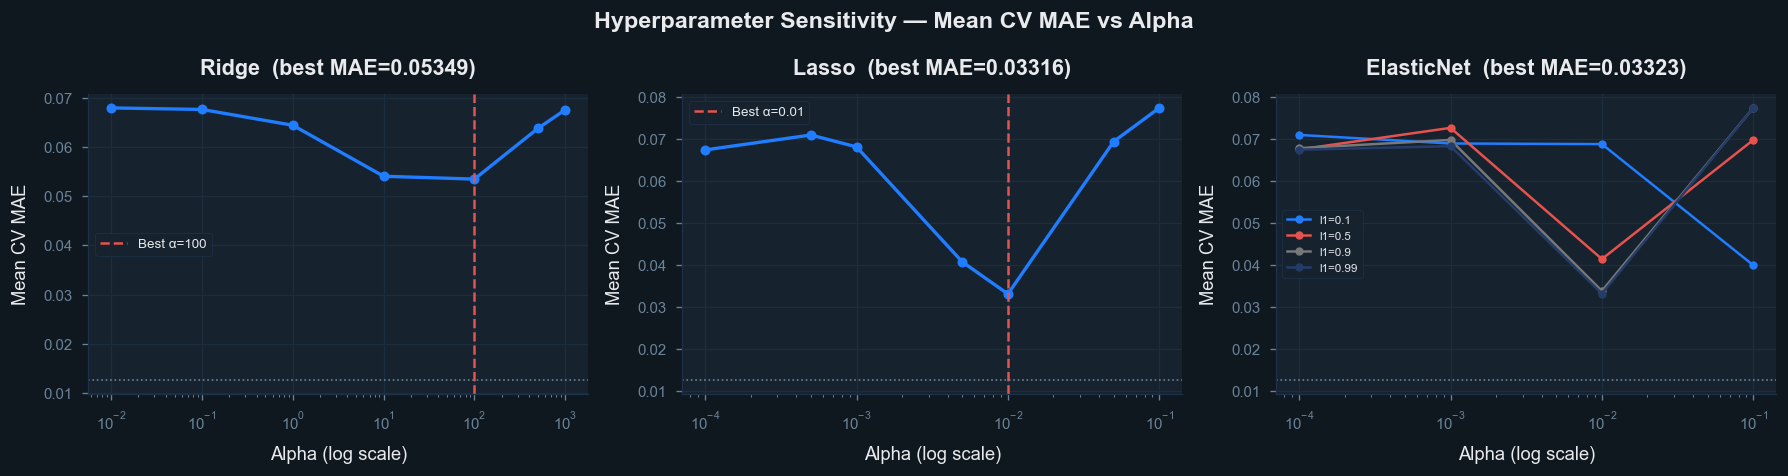

In [8]:
# ── Alpha sensitivity plots for penalised linear models ──────────────────────
linear_models = [m for m in ['Ridge', 'Lasso', 'ElasticNet']
                 if m in tuning_results and tuning_results[m]['all_results']]

fig, axes = plt.subplots(1, len(linear_models), figsize=(5 * len(linear_models), 4))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Hyperparameter Sensitivity — Mean CV MAE vs Alpha',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

if len(linear_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, linear_models):
    ax.set_facecolor(BG_PANEL)
    res = tuning_results[model_name]['all_results']

    if model_name == 'ElasticNet':
        # Group by l1_ratio, plot one line per l1_ratio
        combos_df = pd.DataFrame([{**r['params'], 'mae': r['mean_mae']} for r in res])
        for l1r, grp in combos_df.groupby('model__l1_ratio'):
            grp = grp.sort_values('model__alpha')
            ax.plot(grp['model__alpha'], grp['mae'], marker='o', ms=4,
                    label=f'l1={l1r}', lw=1.5)
        ax.set_xscale('log')
        ax.legend(fontsize=7, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
                  labelcolor=TEXT_PRIMARY)
    else:
        alphas  = [r['params']['model__alpha'] for r in res]
        maes    = [r['mean_mae'] for r in res]
        best_a  = tuning_results[model_name]['best_params']['model__alpha']
        ax.plot(alphas, maes, color=PALETTE[0], marker='o', ms=5, lw=2)
        ax.axvline(best_a, color=REPUBLICAN, ls='--', lw=1.5,
                   label=f'Best α={best_a}')
        ax.set_xscale('log')
        ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
                  labelcolor=TEXT_PRIMARY)

    best_mae = tuning_results[model_name]['best_mae']
    ax.axhline(tuning_results['AR(1) Baseline']['best_mae'],
               color=TEXT_MUTED, ls=':', lw=1, label='AR(1) baseline')
    style_ax(ax, xlabel='Alpha (log scale)', ylabel='Mean CV MAE',
             title=f'{model_name}  (best MAE={best_mae:.5f})')
    ax.tick_params(colors=TEXT_MUTED)

plt.tight_layout()
plt.show()

## 7. Walk-Forward CV Evaluation

We re-run each tuned model over the three CV folds and collect:
- **MAE** (mean absolute error) — main metric, interpretable in probability units
- **RMSE** — penalises large errors more
- **R²** — fraction of variance explained (negative means worse than predicting the mean)
- **DirAcc** — directional accuracy: fraction of days where the predicted direction   (up/down) matches the actual direction. 50 % = random coin flip.

In [9]:
cv_results = []

for model_name, (pipeline, feat_cols, use_text) in TUNED_MODELS.items():
    for fold_i, (train_idx, val_idx) in enumerate(folds, 1):
        m = eval_pipeline(pipeline, feat_cols, train_idx, val_idx)
        cv_results.append({'Model': model_name, 'Fold': fold_i,
                            'MAE': m['MAE'], 'RMSE': m['RMSE'],
                            'R2': m['R2'], 'DirAcc': m['DirAcc']})

cv_df = pd.DataFrame(cv_results)
summary = (cv_df.groupby('Model')[['MAE','RMSE','R2','DirAcc']]
           .agg(['mean','std']).round(5))
summary.columns = ['_'.join(c) for c in summary.columns]
summary = summary.sort_values('MAE_mean')

print("Walk-forward CV — tuned models (mean +/- std across 3 folds):")
print()
print(f"{'Model':<24} {'MAE':>12} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 65)
for m in summary.index:
    print(f"{m:<24} "
          f"{summary.loc[m,'MAE_mean']:.4f}+/-{summary.loc[m,'MAE_std']:.4f}  "
          f"{summary.loc[m,'RMSE_mean']:.4f}  "
          f"{summary.loc[m,'R2_mean']:>8.3f}  "
          f"{summary.loc[m,'DirAcc_mean']:>8.1%}")


Walk-forward CV — tuned models (mean +/- std across 3 folds):

Model                             MAE     RMSE       R2    DirAcc
-----------------------------------------------------------------
AR(1) Baseline           0.0126+/-0.0056  0.0158     0.648     47.5%
Lasso                    0.0332+/-0.0365  0.0373    -2.010     52.7%
Lasso + Text             0.0332+/-0.0365  0.0373    -2.010     52.7%
ElasticNet               0.0332+/-0.0365  0.0374    -2.022     51.4%
XGBoost                  0.0476+/-0.0367  0.0553    -3.595     42.6%
XGBoost + Text           0.0488+/-0.0369  0.0569    -3.904     43.9%
Ridge                    0.0535+/-0.0314  0.0632    -4.216     45.2%
Random Forest            0.0537+/-0.0494  0.0611    -5.621     43.8%


## 8. Results

**Left panel:** MAE per fold per model — shows how consistent each model is across different time periods. High variance across folds suggests overfitting.

**Right panel:** Mean ± std CV MAE with the naive baseline (AR(1) MAE) marked as a red dashed line. Models below this line are at least as good as simply predicting 'tomorrow = today'.

**Key interpretation:** In an efficient market we expect social-media models to barely beat (or fail to beat) the AR(1) baseline.

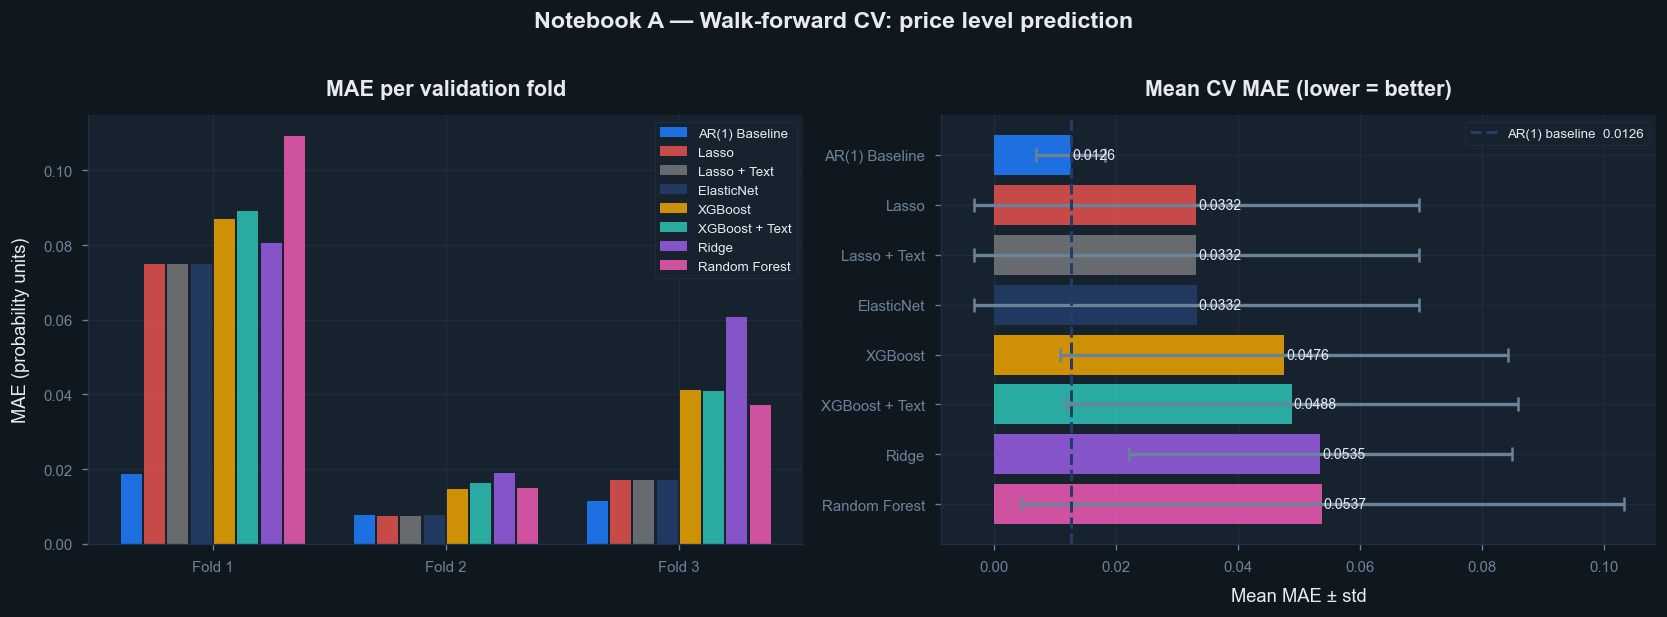

In [10]:
model_names = list(summary.index)
n_models    = len(model_names)
colors      = PALETTE[:n_models]
ar1_mae     = summary.loc['AR(1) Baseline', 'MAE_mean'] if 'AR(1) Baseline' in summary.index else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Notebook A — Walk-forward CV: price level prediction',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold', y=1.02)

# Left: MAE per fold
ax = axes[0]
ax.set_facecolor(BG_PANEL)
x     = np.arange(N_SPLITS)
width = 0.8 / n_models
for i, (name, color) in enumerate(zip(model_names, colors)):
    fold_mae = cv_df[cv_df['Model'] == name].sort_values('Fold')['MAE'].values
    ax.bar(x + i * width - 0.4 + width/2, fold_mae,
           width=width * 0.9, color=color, label=name, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)], color=TEXT_MUTED)
style_ax(ax, ylabel='MAE (probability units)', title='MAE per validation fold')
ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

# Right: mean ± std with AR(1) baseline reference
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
mean_mae = [summary.loc[m, 'MAE_mean'] for m in model_names]
std_mae  = [summary.loc[m, 'MAE_std']  for m in model_names]
bars = ax2.barh(model_names, mean_mae, xerr=std_mae, color=colors,
                alpha=0.85, capsize=4,
                error_kw={'ecolor': TEXT_MUTED, 'capthick': 1.5})
for bar, val in zip(bars, mean_mae):
    ax2.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color=TEXT_PRIMARY, fontsize=8.5)
if ar1_mae:
    ax2.axvline(ar1_mae, color=ACCENT, ls='--', lw=1.8,
                label=f'AR(1) baseline  {ar1_mae:.4f}')
    ax2.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
               labelcolor=TEXT_PRIMARY)
ax2.invert_yaxis()
ax2.tick_params(colors=TEXT_MUTED)
style_ax(ax2, xlabel='Mean MAE ± std', title='Mean CV MAE (lower = better)')

plt.tight_layout()
plt.show()


## 9. Predictions vs Actual — Best Model

The best model by CV MAE is shown against the held-in CV validation windows. Grey shaded areas mark the held-out test period (not used during tuning). A flat prediction line indicates that the model has learned to predict a constant value (often the training mean) — a sign that the signal is too weak to extract.

Best model: AR(1) Baseline  (CV MAE = 0.01258)


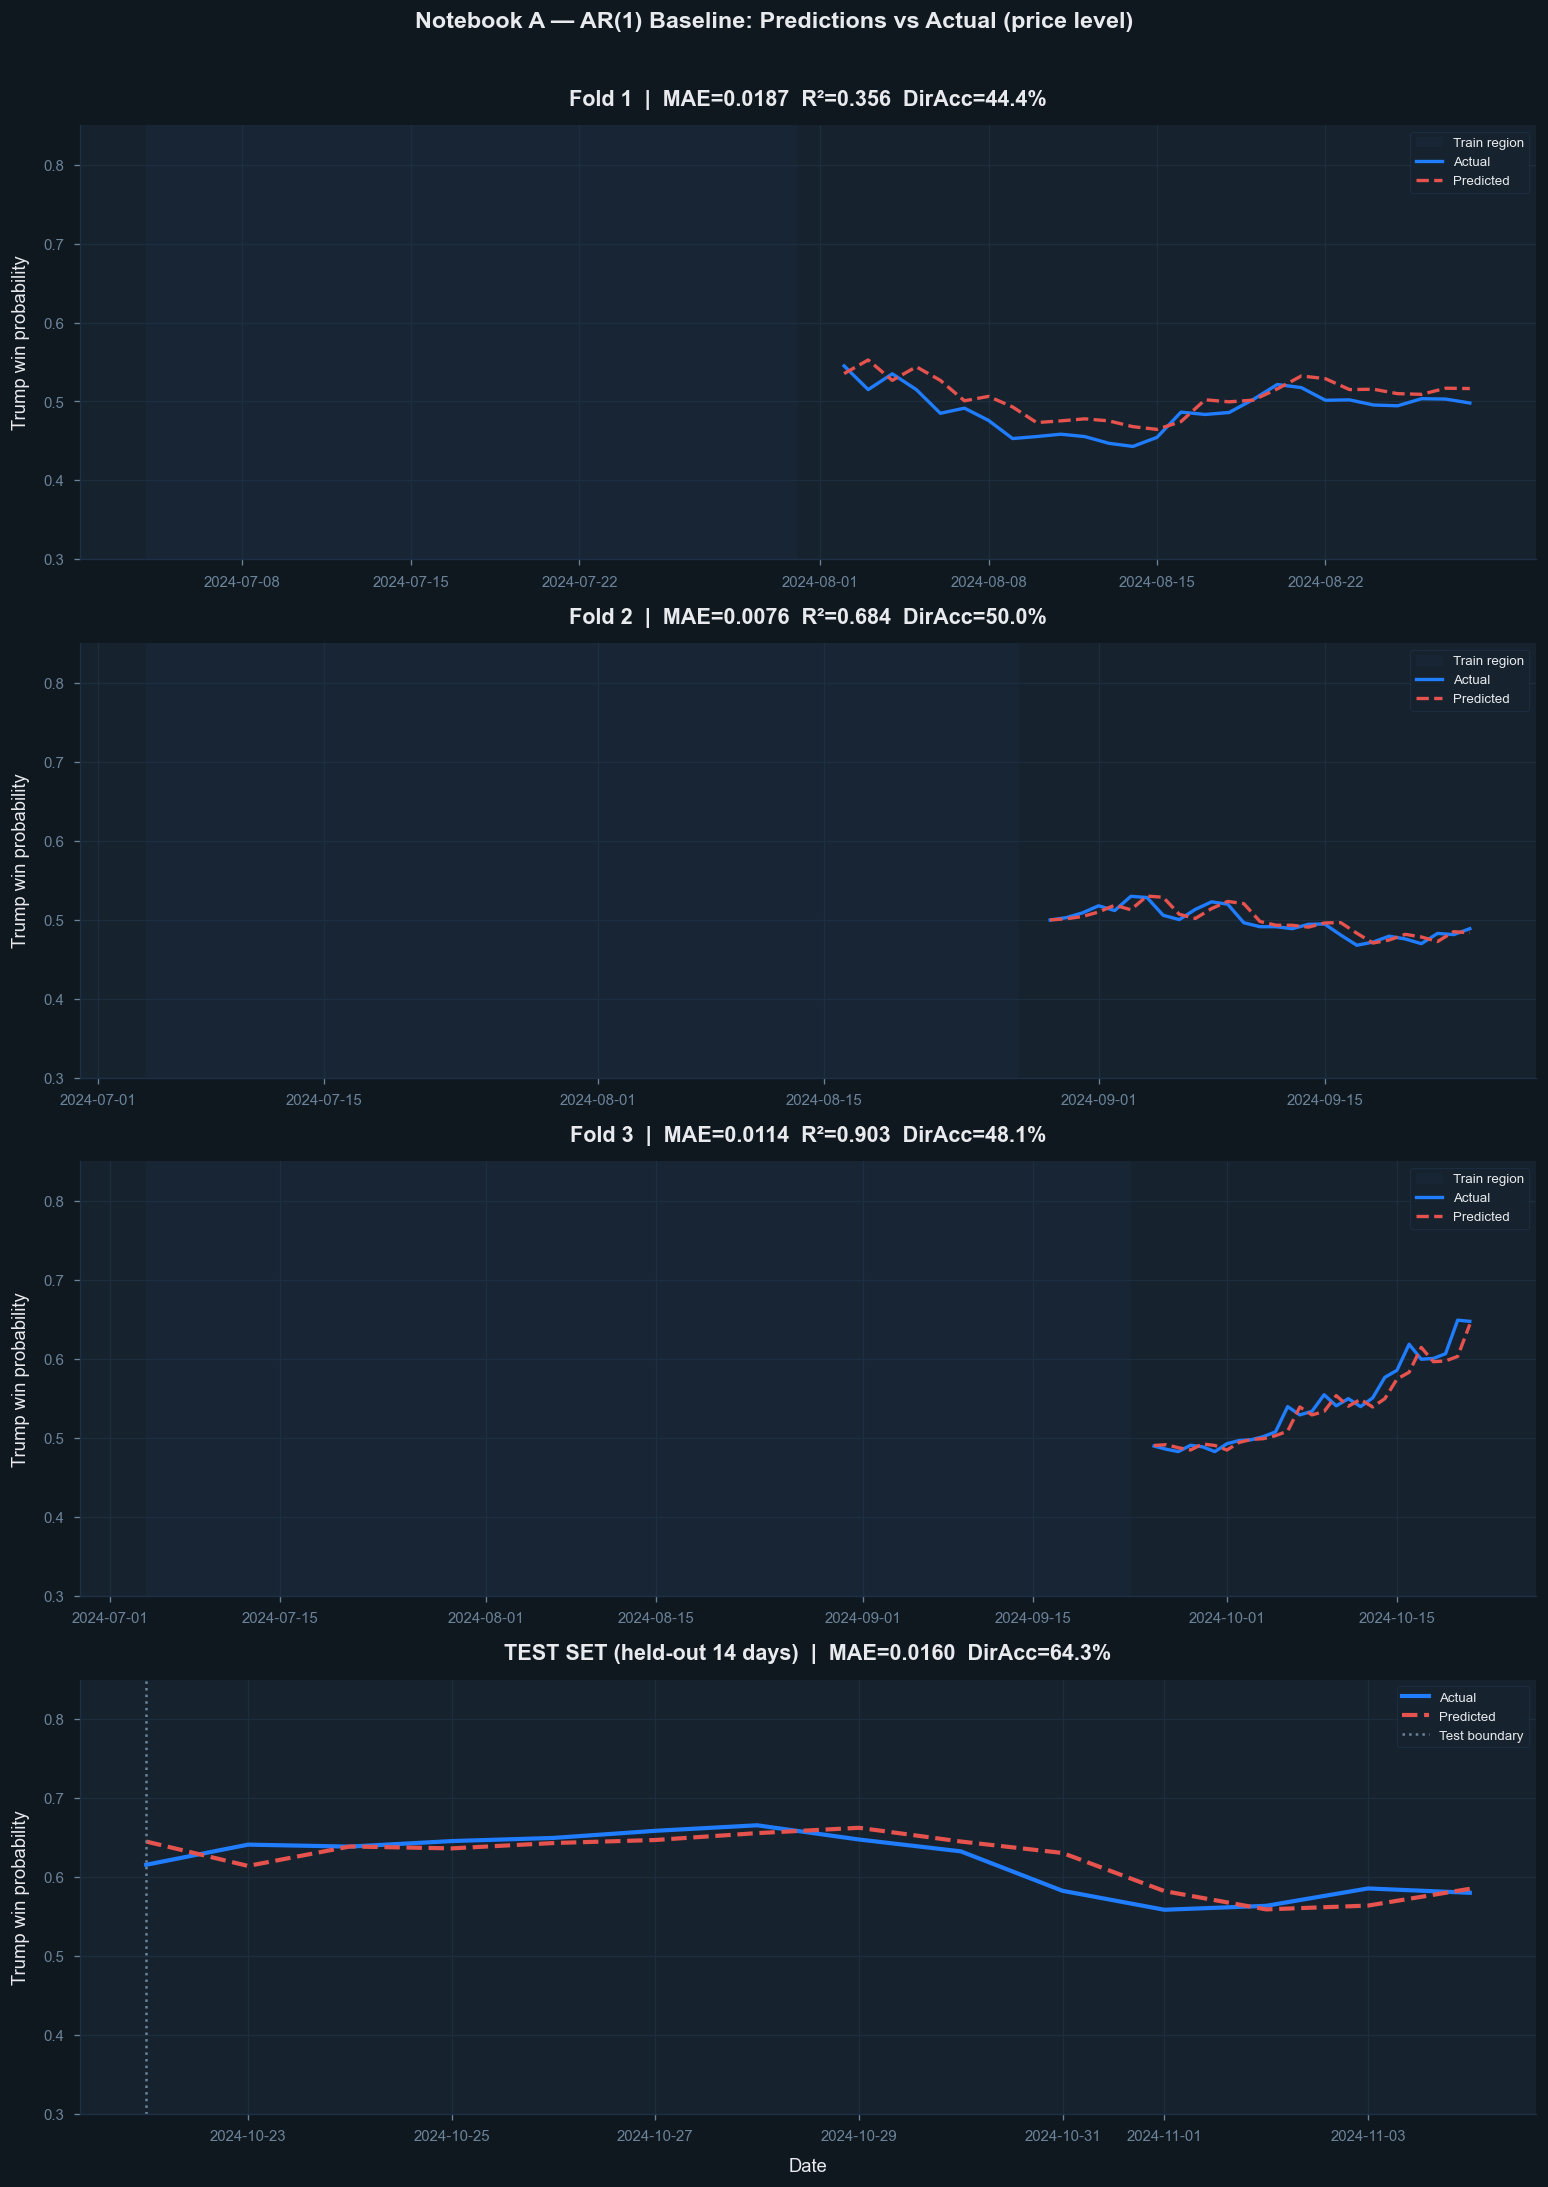

In [11]:
best_name = summary['MAE_mean'].idxmin()
best_pipe, best_feats, _use_text = TUNED_MODELS[best_name]
print(f"Best model: {best_name}  (CV MAE = {summary.loc[best_name,'MAE_mean']:.5f})")

fig, axes = plt.subplots(N_SPLITS + 1, 1,
                         figsize=(13, min(4.5 * (N_SPLITS + 1), 22)))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(f'Notebook A — {best_name}: Predictions vs Actual (price level)',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold', y=1.01)

for fold_i, (train_idx, val_idx) in enumerate(folds):
    ax = axes[fold_i]
    ax.set_facecolor(BG_PANEL)
    m = eval_pipeline(best_pipe, best_feats, train_idx, val_idx)
    ax.fill_betweenx([0.2, 0.9],
                     df['date'].iloc[train_idx[0]], df['date'].iloc[train_idx[-1]],
                     color=ACCENT, alpha=0.10, label='Train region')
    ax.plot(m['dates'], m['y_true'], color=DEMOCRAT,   lw=2,   label='Actual')
    ax.plot(m['dates'], m['y_pred'], color=REPUBLICAN, lw=2,   ls='--', label='Predicted')
    style_ax(ax, ylabel='Trump win probability',
             title=f'Fold {fold_i+1}  |  MAE={m["MAE"]:.4f}  R²={m["R2"]:.3f}  DirAcc={m["DirAcc"]:.1%}')
    ax.set_ylim(0.30, 0.85)
    ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

# Final panel: held-out test set
ax = axes[N_SPLITS]
ax.set_facecolor(BG_PANEL)
pipe_final = clone(best_pipe)
pipe_final.fit(df[best_feats].iloc[tv_idx], df[TARGET].iloc[tv_idx])
y_test_pred = pipe_final.predict(df[best_feats].iloc[test_idx])
y_test_true = df[TARGET].iloc[test_idx].values
dates_test  = df['date'].iloc[test_idx].values

ax.plot(dates_test, y_test_true, color=DEMOCRAT,   lw=2.5, label='Actual')
ax.plot(dates_test, y_test_pred, color=REPUBLICAN, lw=2.5, ls='--', label='Predicted')
ax.axvline(dates_test[0], color=TEXT_MUTED, ls=':', lw=1.5, label='Test boundary')
mae_t = mean_absolute_error(y_test_true, y_test_pred)
da_t  = directional_accuracy(y_test_true, y_test_pred,
                              df['polymarket_trump_prob_lag1'].iloc[test_idx].values)
style_ax(ax, xlabel='Date', ylabel='Trump win probability',
         title=f'TEST SET (held-out 14 days)  |  MAE={mae_t:.4f}  DirAcc={da_t:.1%}')
ax.set_ylim(0.30, 0.85)
ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()


## 10. Feature Importance

**Left (Lasso coefficients):** Non-zero coefficients show which features the L1 penalty kept. Lasso zeros out unimportant features, so the surviving ones are those with the strongest marginal predictive power given the others.

**Right (XGBoost gain):** Importance is measured by average gain — how much each feature reduces the prediction error when used in a tree split. XGBoost can capture non-linear interactions that linear models miss.

**Note on SBERT features:** `sbert_*_pc1` etc. are principal components of dense semantic embeddings. A high importance for PC1 of news text means the dominant axis of variation in news semantics is predictive of price levels.

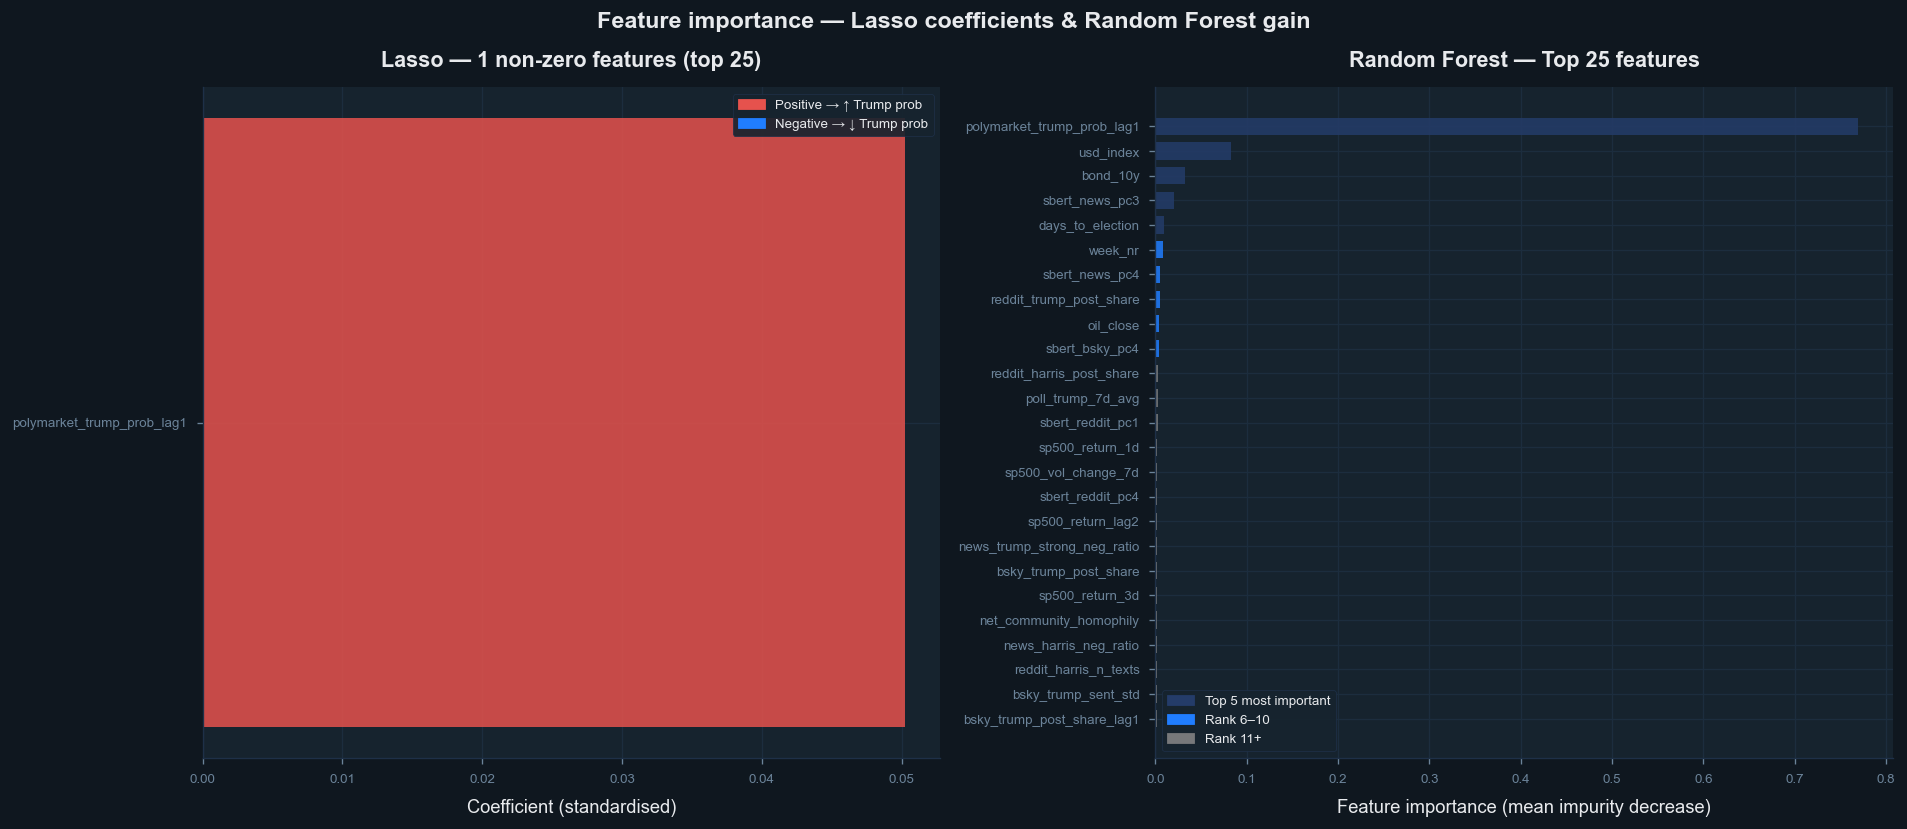

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Feature importance — Lasso coefficients & Random Forest gain',
             color=TEXT_PRIMARY, fontsize=14, fontweight='bold')

# Left: Lasso (non-zero features, sign = direction)
lasso_pipe, lasso_feats, _ = TUNED_MODELS['Lasso']
lp = clone(lasso_pipe)
lp.fit(df[lasso_feats].iloc[tv_idx], df[TARGET].iloc[tv_idx])
coef = lp.named_steps['model'].coef_
coef_df = (pd.DataFrame({'feature': lasso_feats, 'coef': coef})
           .query('coef != 0')
           .assign(abs_coef=lambda x: x['coef'].abs())
           .sort_values('abs_coef', ascending=False).head(25))

ax = axes[0]
ax.set_facecolor(BG_PANEL)
bar_colors = [REPUBLICAN if c > 0 else DEMOCRAT for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=bar_colors, alpha=0.85, height=0.7)
ax.axvline(0, color=TEXT_MUTED, lw=1)
ax.tick_params(colors=TEXT_MUTED, labelsize=8)
n_nonzero = (coef != 0).sum()
style_ax(ax, xlabel='Coefficient (standardised)',
         title=f'Lasso — {n_nonzero} non-zero features (top 25)')
ax.invert_yaxis()
ax.legend(handles=[
    mpatches.Patch(color=REPUBLICAN, label='Positive → ↑ Trump prob'),
    mpatches.Patch(color=DEMOCRAT,   label='Negative → ↓ Trump prob'),
], facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

# Right: Random Forest with gradient colors by importance rank
rf_pipe, rf_feats, _ = TUNED_MODELS['Random Forest']
rfp = clone(rf_pipe)
rfp.fit(df[rf_feats].iloc[tv_idx], df[TARGET].iloc[tv_idx])
importances = rfp.named_steps['model'].feature_importances_
fi_df = (pd.DataFrame({'feature': rf_feats, 'importance': importances})
         .sort_values('importance', ascending=False).head(25))

n = len(fi_df)
rf_colors = [ACCENT if i < 5 else DEMOCRAT if i < 10 else NEUTRAL
             for i in range(n)]
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)
ax2.barh(fi_df['feature'], fi_df['importance'], color=rf_colors, alpha=0.85, height=0.7)
ax2.tick_params(colors=TEXT_MUTED, labelsize=8)
style_ax(ax2, xlabel='Feature importance (mean impurity decrease)',
         title='Random Forest — Top 25 features')
ax2.invert_yaxis()
ax2.legend(handles=[
    mpatches.Patch(color=ACCENT,   label='Top 5 most important'),
    mpatches.Patch(color=DEMOCRAT, label='Rank 6–10'),
    mpatches.Patch(color=NEUTRAL,  label='Rank 11+'),
], facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

plt.tight_layout()
plt.show()


## Feature Relevance — Model-free Correlation with Price Level

All features ranked by |Pearson r| with `polymarket_trump_prob`. **Note:** because the price level is highly autocorrelated (AR(1) r ≈ 0.99), the lag feature dominates. The interesting features are those that still show independent signal after the AR(1) component.

Compare these rankings with Notebook B (price *change*) to see which features genuinely capture daily movement vs. which are merely correlated with the level.

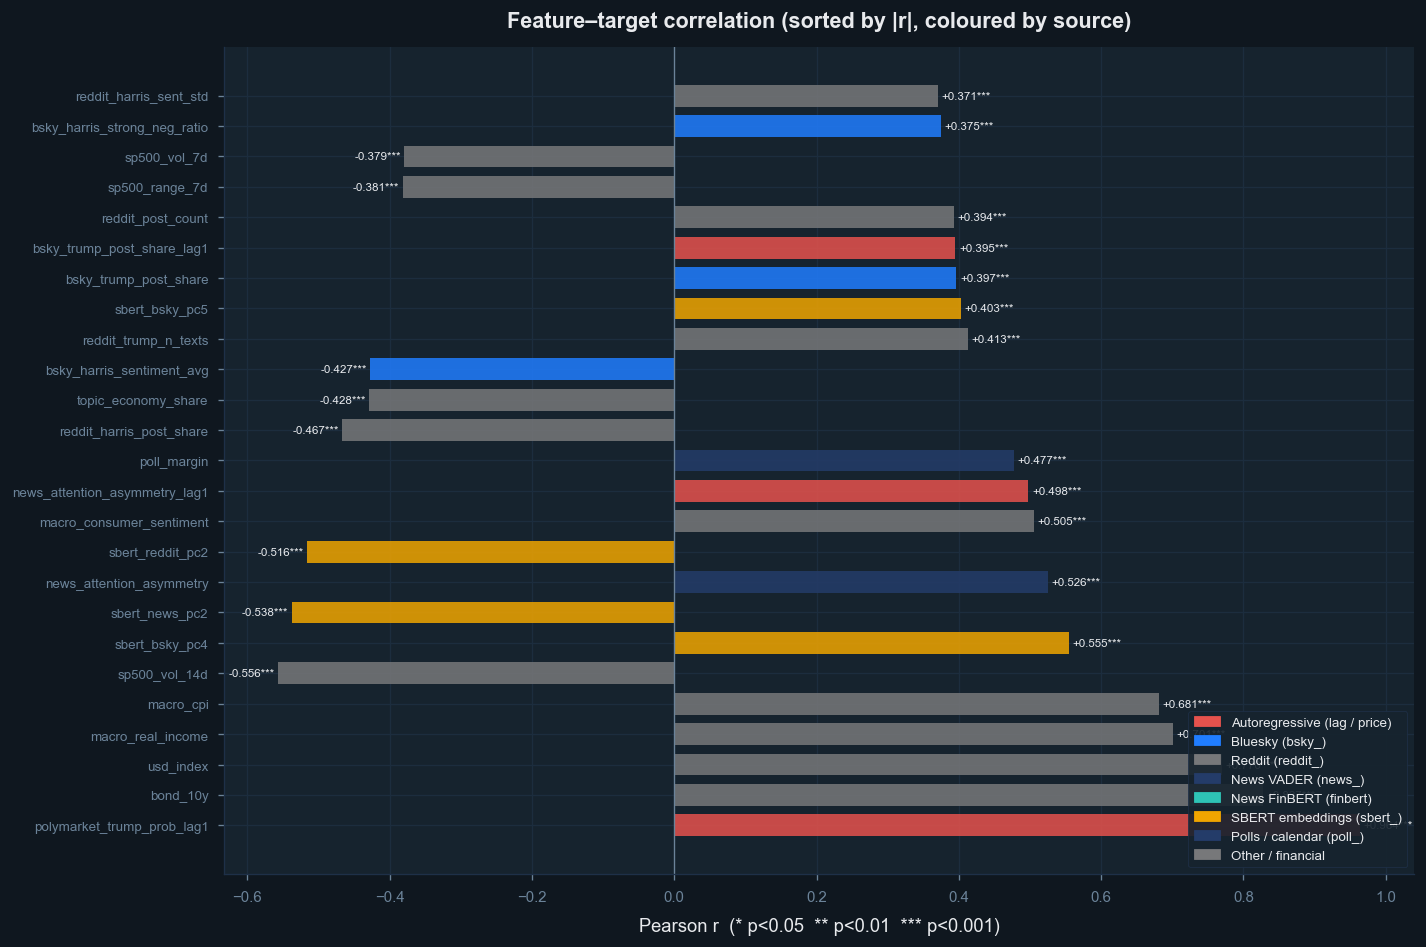

In [13]:
from scipy.stats import pearsonr
import matplotlib.patches as mpatches

corr_rows_a = []
for col in FEAT_ALL:
    if col in df.columns and col != TARGET:
        _d = df[[col, TARGET]].dropna()
        if len(_d) > 20:
            r, p = pearsonr(_d[col].values, _d[TARGET].values)
            corr_rows_a.append({'feature': col, 'r': r, 'abs_r': abs(r), 'p': p})

corr_df_a = (pd.DataFrame(corr_rows_a)
             .sort_values('abs_r', ascending=False)
             .head(25).reset_index(drop=True))

def _src_color_a(feat):
    if 'lag'      in feat or 'prob' in feat: return REPUBLICAN
    if 'sbert_'   in feat: return PALETTE[4]
    if 'finbert'  in feat: return PALETTE[5]
    if 'news_'    in feat: return ACCENT
    if 'bsky_'    in feat: return DEMOCRAT
    if 'reddit_'  in feat: return PALETTE[2]
    if 'poll_'    in feat or 'days_to' in feat: return PALETTE[3]
    return NEUTRAL

c_colors_a = [_src_color_a(f) for f in corr_df_a['feature']]

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
ax.barh(range(len(corr_df_a)), corr_df_a['r'].values,
        color=c_colors_a, height=0.72, alpha=0.85)
ax.set_yticks(range(len(corr_df_a)))
ax.set_yticklabels(corr_df_a['feature'].values, fontsize=8, color=TEXT_PRIMARY)
ax.axvline(0, color=TEXT_MUTED, lw=0.8)
for i, (r, p) in enumerate(zip(corr_df_a['r'], corr_df_a['p'])):
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    offset = 0.005 if r >= 0 else -0.005
    ax.text(r + offset, i, f'{r:+.3f}{sig}', va='center',
            fontsize=7, color=TEXT_PRIMARY,
            ha='left' if r >= 0 else 'right')
style_ax(ax, xlabel='Pearson r  (* p<0.05  ** p<0.01  *** p<0.001)',
         title='Feature–target correlation (sorted by |r|, coloured by source)',
         grid_axis='x')
ax.legend(handles=[
    mpatches.Patch(color=REPUBLICAN, label='Autoregressive (lag / price)'),
    mpatches.Patch(color=DEMOCRAT,   label='Bluesky (bsky_)'),
    mpatches.Patch(color=PALETTE[2], label='Reddit (reddit_)'),
    mpatches.Patch(color=ACCENT,     label='News VADER (news_)'),
    mpatches.Patch(color=PALETTE[5], label='News FinBERT (finbert)'),
    mpatches.Patch(color=PALETTE[4], label='SBERT embeddings (sbert_)'),
    mpatches.Patch(color=PALETTE[3], label='Polls / calendar (poll_)'),
    mpatches.Patch(color=NEUTRAL,    label='Other / financial'),
], facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
   fontsize=8, loc='lower right')
ax.tick_params(colors=TEXT_MUTED)
plt.tight_layout()
plt.show()


## 11. Final Test Set Evaluation

The last 14 days of the time series are held out from the beginning and **never** used during feature selection, tuning, or CV. We now evaluate each tuned model on this completely unseen data.

This is the only honest estimate of out-of-sample performance. CV results may be optimistic because the tuning loop sees all three CV folds; the test set has seen nothing.

**Market efficiency implication:** If no model consistently outperforms AR(1) here, it supports the hypothesis that prediction markets efficiently incorporate publicly available social media and news information.

Model                       MAE     RMSE       R²    DirAcc
------------------------------------------------------------
AR(1) Baseline           0.0160   0.0202    0.682    64.3%
Ridge                    0.0375   0.0443   -0.535    57.1%
Lasso                    0.0195   0.0225    0.604    50.0%
ElasticNet               0.0195   0.0225    0.606    50.0%
Random Forest            0.0264   0.0297    0.313    42.9%
XGBoost                  0.0317   0.0341    0.095    42.9%
Lasso + Text             0.0195   0.0225    0.604    50.0%
XGBoost + Text           0.0298   0.0321    0.197    42.9%


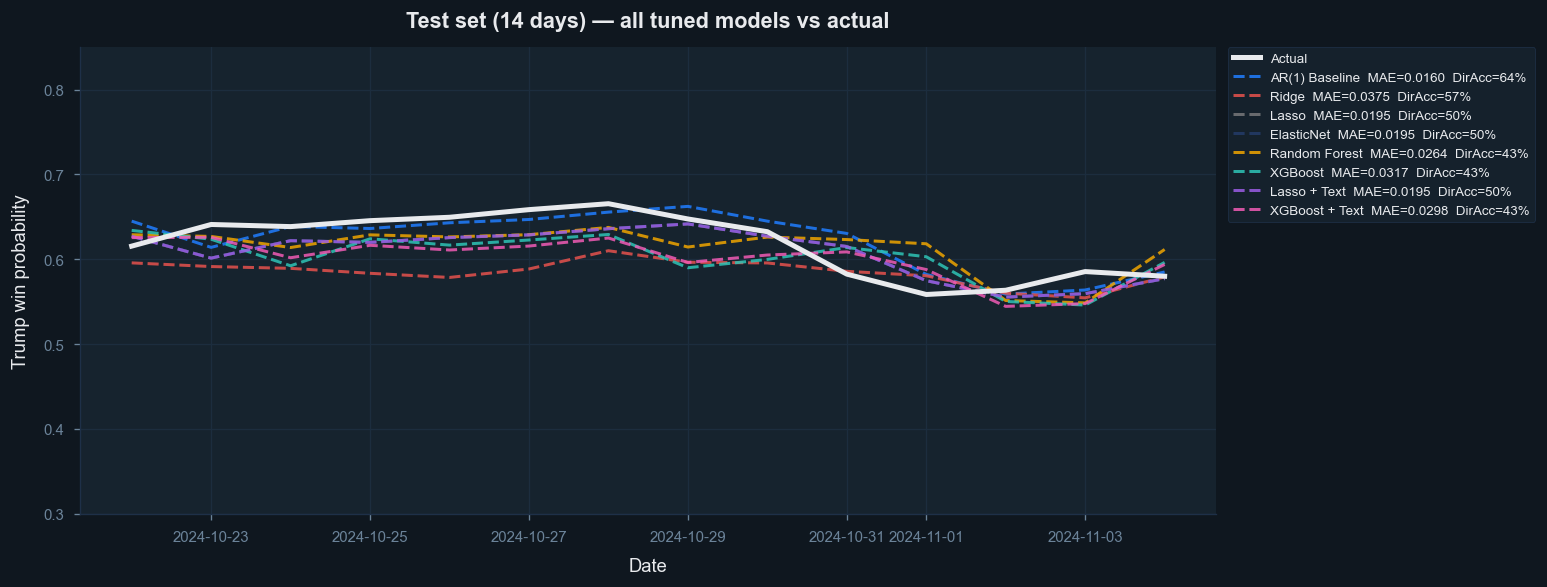

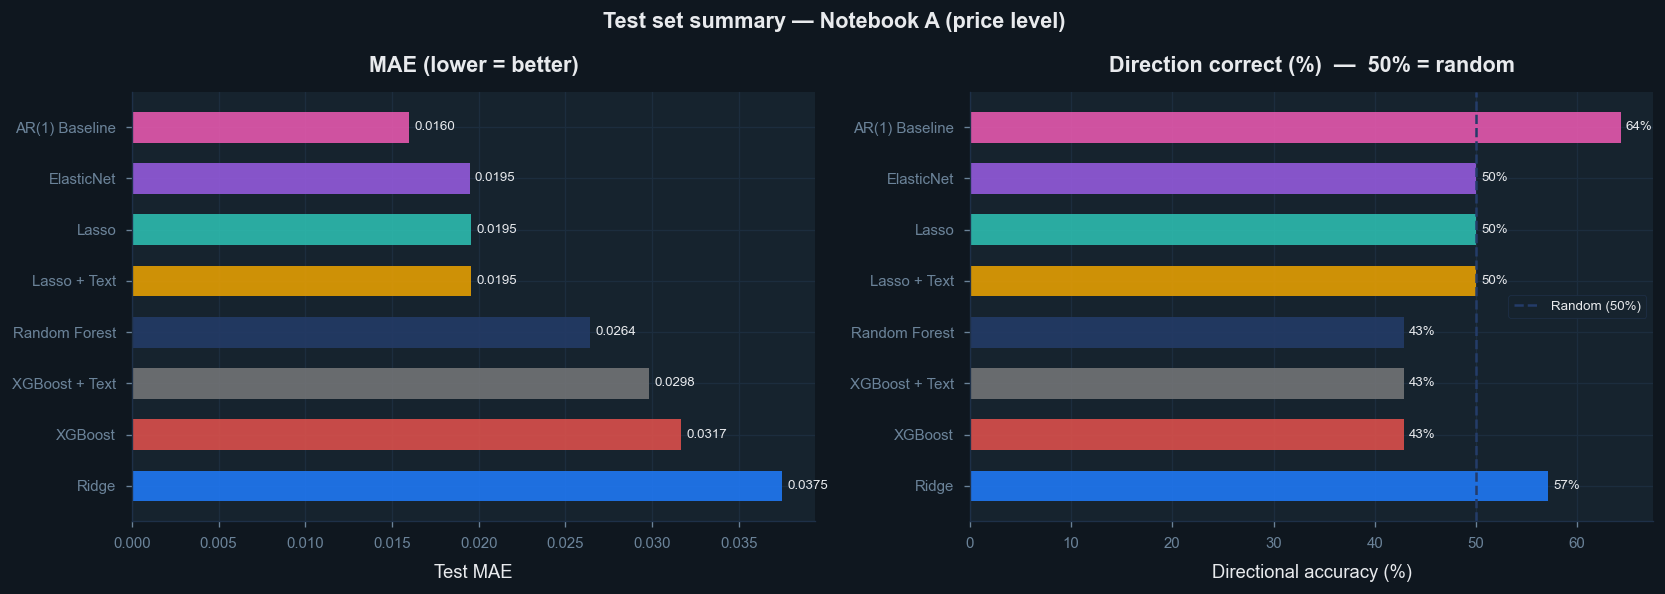

In [14]:
test_res = {}
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'DirAcc':>9}")
print("-" * 60)
for model_name, (pipeline, feat_cols, _use_text) in TUNED_MODELS.items():
    pipe = clone(pipeline)
    pipe.fit(df[feat_cols].iloc[tv_idx], df[TARGET].iloc[tv_idx])
    y_pred = pipe.predict(df[feat_cols].iloc[test_idx])
    y_true = df[TARGET].iloc[test_idx].values
    lag_t  = df['polymarket_trump_prob_lag1'].iloc[test_idx].values
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    da   = directional_accuracy(y_true, y_pred, lag_t)
    test_res[model_name] = {'y_pred': y_pred, 'y_true': y_true,
                             'MAE': mae, 'RMSE': rmse, 'R2': r2, 'DirAcc': da}
    print(f"{model_name:<22} {mae:>8.4f} {rmse:>8.4f} {r2:>8.3f} {da:>8.1%}")

# Plot 1: all models' predictions on test set
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

dates_test = df['date'].iloc[test_idx].values
first_model = list(test_res.keys())[0]
ax.plot(dates_test, test_res[first_model]['y_true'],
        color=TEXT_PRIMARY, lw=3, label='Actual', zorder=5)
for (name, res), color in zip(test_res.items(), PALETTE):
    ax.plot(dates_test, res['y_pred'], color=color, lw=1.8, ls='--', alpha=0.85,
            label=f"{name}  MAE={res['MAE']:.4f}  DirAcc={res['DirAcc']:.0%}")
style_ax(ax, xlabel='Date', ylabel='Trump win probability',
         title='Test set (14 days) — all tuned models vs actual')
ax.set_ylim(0.30, 0.85)
ax.legend(fontsize=8, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
          labelcolor=TEXT_PRIMARY, loc='upper left',
          bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# Plot 2: MAE + R² comparison bar chart (sorted by MAE)
test_df = pd.DataFrame([
    {'Model': k, 'MAE': v['MAE'], 'R2': v['R2'], 'DirAcc': v['DirAcc']}
    for k, v in test_res.items()
]).sort_values('MAE').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Test set summary — Notebook A (price level)',
             color=TEXT_PRIMARY, fontsize=13, fontweight='bold')

for ax, col, xlabel, title in zip(
        axes,
        ['MAE',  'DirAcc'],
        ['Test MAE', 'Directional accuracy (%)'],
        ['MAE (lower = better)', 'Direction correct (%)  —  50% = random']):
    ax.set_facecolor(BG_PANEL)
    vals = test_df[col].values * (100 if col == 'DirAcc' else 1)
    bars = ax.barh(test_df['Model'][::-1], vals[::-1],
                   color=PALETTE[:len(test_df)], alpha=0.85, height=0.6)
    for bar, v in zip(bars, vals[::-1]):
        ax.text(v + (0.0003 if col == 'MAE' else 0.5),
                bar.get_y() + bar.get_height()/2,
                f'{v:.4f}' if col == 'MAE' else f'{v:.0f}%',
                va='center', fontsize=8, color=TEXT_PRIMARY)
    if col == 'DirAcc':
        ax.axvline(50, color=ACCENT, ls='--', lw=1.5, label='Random (50%)')
        ax.legend(fontsize=8, facecolor=BG_PANEL, labelcolor=TEXT_PRIMARY)
    ax.tick_params(colors=TEXT_MUTED)
    style_ax(ax, xlabel=xlabel, title=title)

plt.tight_layout()
plt.show()
